<a href="https://colab.research.google.com/github/logansivam/Testing/blob/main/DMDW_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Business Understanding

The objective of this project is to help food delivery drivers estimate how many orders they can complete in a day.
The prediction is based on factors such as weather conditions, road traffic density, peak hours, and delivery time.

This insight allows drivers to plan their working hours more effectively and helps delivery platforms improve resource allocation.

# 2. Data Understanding

The dataset contains historical food delivery records including delivery time, traffic conditions, weather, and rider information.
Initial exploration is conducted to understand data structure, data types, and potential quality issues.

In [ ]:
df.head()
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Delivery_person_Age          45593 non-null  float64
 1   Delivery_person_Ratings      45593 non-null  float64
 2   Restaurant_latitude          45593 non-null  float64
 3   Restaurant_longitude         45593 non-null  float64
 4   Delivery_location_latitude   45593 non-null  float64
 5   Delivery_location_longitude  45593 non-null  float64
 6   Order_Date                   45593 non-null  float64
 7   Time_Orderd                  45593 non-null  float64
 8   Time_Order_picked            45593 non-null  float64
 9   Weatherconditions            45593 non-null  float64
 10  Road_traffic_density         45593 non-null  float64
 11  Vehicle_condition            45593 non-null  float64
 12  Type_of_order                45593 non-null  float64
 13  Type_of_vehicle 

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
count,4.559300e+04,4.559300e+04,4.559300e+04,4.559300e+04,4.559300e+04,4.559300e+04,4.559300e+04,4.559300e+04,4.559300e+04,4.559300e+04,4.559300e+04,4.559300e+04,4.559300e+04,4.559300e+04,4.559300e+04,4.559300e+04,4.559300e+04,45593.000000
mean,1.298186e-16,-7.870157e-17,3.568844e-17,4.391704e-16,2.474814e-16,-3.509623e-16,-1.281043e-16,-6.849375e-17,-8.033794e-17,4.877939e-17,8.727303e-17,1.215589e-17,6.841582e-17,-6.794829e-17,3.428583e-17,-4.232742e-16,1.449356e-17,16.294607
std,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,9.383806
min,-1.809744e+00,-6.763089e+00,-5.855000e+00,-6.930682e+00,-2.379698e+00,-3.354189e+00,-1.663072e+00,-2.183383e+00,-2.093302e+00,-1.487295e+00,-1.822692e+00,-1.219656e+00,-1.350081e+00,-3.732046e+00,-1.103366e+00,-6.490555e+00,-5.624586e-01,0.000000
25%,-8.247382e-01,-1.725422e-01,-4.990147e-01,1.284192e-01,-6.103214e-01,1.152681e-01,-8.848945e-01,-5.076739e-01,-6.885002e-01,-1.011991e+00,-7.883387e-01,-1.219656e+00,-4.558781e-01,-4.123337e-01,-1.103366e+00,-9.372238e-02,-5.624586e-01,9.000000
50%,-3.899582e-03,1.270281e-01,1.868314e-01,2.476540e-01,1.593376e-01,2.441865e-01,-2.889939e-02,2.522407e-01,2.773011e-01,-6.138204e-02,2.460141e-01,-2.783945e-02,4.383247e-01,-4.123337e-01,2.495214e-01,-9.372238e-02,-5.624586e-01,16.000000
75%,8.169390e-01,7.261688e-01,6.976690e-01,3.414162e-01,7.252669e-01,3.438366e-01,9.049134e-01,7.783355e-01,7.865417e-01,8.892265e-01,1.280367e+00,1.163977e+00,1.332527e+00,1.247522e+00,2.495214e-01,-9.372238e-02,2.405278e-01,22.000000
max,1.801945e+00,1.624880e+00,1.697776e+00,7.954291e-01,1.852596e+00,8.389650e-01,1.683091e+00,1.245975e+00,1.278222e+00,1.364531e+00,2.314720e+00,2.355793e+00,1.332527e+00,1.247522e+00,4.308183e+00,6.303110e+00,1.846501e+00,44.000000


## 3.1 Data Extraction

The dataset is loaded from a CSV file into a Pandas DataFrame for processing.

In [ ]:
import pandas as pd
df = pd.read_csv('train.csv')


## 3.2 Data Cleaning

Rows with missing, invalid, or unrealistic values are removed to ensure data quality.
This step improves model accuracy and reliability.

In [ ]:
# Store dataset size before cleaning
before_cleaning = df.shape


In [ ]:
# Remove rows with missing values
df = df.dropna()


In [ ]:
# Remove rows with invalid delivery time (zero or negative)
df['Time_taken(min)'] = df['Time_taken(min)'].str.extract(r'(\d+)').astype(int)
df = df[df['Time_taken(min)'] > 0]


In [ ]:
df['Delivery_person_Age'] = pd.to_numeric(df['Delivery_person_Age'], errors='coerce')
df = df.dropna(subset=['Delivery_person_Age'])
df = df[(df['Delivery_person_Age'] >= 18) & (df['Delivery_person_Age'] <= 60)]

In [ ]:
df['Delivery_person_Ratings'] = pd.to_numeric(df['Delivery_person_Ratings'], errors='coerce')
df = df.dropna(subset=['Delivery_person_Ratings'])
df = df[(df['Delivery_person_Ratings'] >= 1) & (df['Delivery_person_Ratings'] <= 5)]

In [ ]:
# Show first 10 rows of the cleaned dataset
df.head(10)


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,24
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,33
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,26
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,21
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,30
5,0x9bb4,HYDRES09DEL03,22.0,4.8,17.431668,78.408321,17.461668,78.438321,11-03-2022,21:20:00,21:30:00,conditions Cloudy,Jam,0,Buffet,motorcycle,1,No,Urban,26
6,0x95b4,RANCHIRES15DEL01,33.0,4.7,23.369746,85.339820,23.479746,85.449820,04-03-2022,19:15:00,19:30:00,conditions Fog,Jam,1,Meal,scooter,1,No,Metropolitian,40
7,0x9eb2,MYSRES15DEL02,35.0,4.6,12.352058,76.606650,12.482058,76.736650,14-03-2022,17:25:00,17:30:00,conditions Cloudy,Medium,2,Meal,motorcycle,1,No,Metropolitian,32
8,0x1102,HYDRES05DEL02,22.0,4.8,17.433809,78.386744,17.563809,78.516744,20-03-2022,20:55:00,21:05:00,conditions Stormy,Jam,0,Buffet,motorcycle,1,No,Metropolitian,34
9,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55:00,22:10:00,conditions Fog,Jam,2,Snack,motorcycle,3,No,Metropolitian,46


In [ ]:
# Check data types after cleaning
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 43594 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           43594 non-null  object 
 1   Delivery_person_ID           43594 non-null  object 
 2   Delivery_person_Age          43594 non-null  float64
 3   Delivery_person_Ratings      43594 non-null  float64
 4   Restaurant_latitude          43594 non-null  float64
 5   Restaurant_longitude         43594 non-null  float64
 6   Delivery_location_latitude   43594 non-null  float64
 7   Delivery_location_longitude  43594 non-null  float64
 8   Order_Date                   43594 non-null  object 
 9   Time_Orderd                  43594 non-null  object 
 10  Time_Order_picked            43594 non-null  object 
 11  Weatherconditions            43594 non-null  object 
 12  Road_traffic_density         43594 non-null  object 
 13  Vehicle_condition    

In [ ]:
# Dataset size comparison
after_cleaning = df.shape

print("Before cleaning:", before_cleaning)
print("After cleaning:", after_cleaning)


Before cleaning: (45593, 20)
After cleaning: (43594, 20)


## 3.3 Data Transformation

Data types are converted and new features are created to support modeling.

In [ ]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%d-%m-%Y')
df['Order_Hour'] = pd.to_datetime(df['Time_Orderd'], format='%H:%M:%S').dt.hour


In [ ]:
# Peak hour definition (Lunch & Dinner)
df['Peak_Hour'] = df['Order_Hour'].apply(
    lambda x: 1 if (11 <= x <= 14 or 18 <= x <= 21) else 0
)


## 3.4 Data Integration

All cleaned and transformed data is integrated into a single analytical dataset.


In [ ]:
df.shape


(43594, 22)

## 3.5 Data Loading

The cleaned dataset represents the staging area of a conceptual data warehouse and is used for analytical modeling.


# 4. Data Warehouse Design

A conceptual star schema is designed for analytical purposes.

Fact Table:
- Delivery_Fact (Delivery Time, Order Count)

Dimension Tables:
- Rider_Dim
- Time_Dim
- Weather_Dim
- Traffic_Dim
- Location_Dim

# 5. Modeling

A regression model is built to predict delivery time, which is later used to estimate the number of orders a driver can complete per day.

In [ ]:
# Final cleaned dataset used for prediction
cleaned_df = df.copy()

cleaned_df.head()


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),Order_Hour,Peak_Hour
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,24,11,1
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,33,19,1
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,26,8,0
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,21,18,1
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,30,13,1


In [ ]:
# Features used for prediction
feature_columns = [
    'Delivery_person_Age',
    'Delivery_person_Ratings',
    'Restaurant_latitude',
    'Restaurant_longitude',
    'Delivery_location_latitude',
    'Delivery_location_longitude',
    'Order_Hour',
    'Peak_Hour',
    'Weatherconditions',
    'Road_traffic_density',
    'Vehicle_condition',
    'Type_of_order',
    'Type_of_vehicle',
    'multiple_deliveries',
    'Festival',
    'City'
]

target_column = 'Time_taken(min)'


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor


In [ ]:
X = df[['Delivery_person_Age', 'Delivery_person_Ratings', 'Order_Hour', 'Peak_Hour']]
y = df['Time_taken(min)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

# 6. Evaluation

The model is evaluated using Mean Absolute Error (MAE).

In [ ]:
from sklearn.metrics import mean_absolute_error

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mae


5.593347785808255

# 7. Decision Support

Using predicted delivery time, the number of orders a driver can complete per day is estimated.

The predicted delivery time is used to estimate the number of orders a driver can complete in a day.
This estimation considers driver characteristics, environmental conditions, and traffic factors.


In [ ]:
# Assume driver works 8 hours per day
working_minutes = 8 * 60

df['Predicted_Time'] = model.predict(X)
df['Estimated_Orders_Per_Day'] = working_minutes / df['Predicted_Time']

df[['Estimated_Orders_Per_Day']].head()


,Estimated_Orders_Per_Day
0,15.829475
1,13.740149
2,20.299979
3,15.609719
4,15.399393


In [ ]:
# Show final output for drivers
df[[
    'Delivery_person_Age',
    'Delivery_person_Ratings',
    'Weatherconditions',
    'Road_traffic_density',
    'Peak_Hour',
    'Estimated_Orders_Per_Day'
]].head(10)


,Delivery_person_Age,Delivery_person_Ratings,Weatherconditions,Road_traffic_density,Peak_Hour,Estimated_Orders_Per_Day
0,37.0,4.9,conditions Sunny,High,1,15.829475
1,34.0,4.5,conditions Stormy,Jam,1,13.740149
2,23.0,4.4,conditions Sandstorms,Low,0,20.299979
3,38.0,4.7,conditions Sunny,Medium,1,15.609719
4,32.0,4.6,conditions Cloudy,High,1,15.399393
5,22.0,4.8,conditions Cloudy,Jam,1,19.376587
6,33.0,4.7,conditions Fog,Jam,1,16.171061
7,35.0,4.6,conditions Cloudy,Medium,0,16.634629
8,22.0,4.8,conditions Stormy,Jam,1,21.398974
9,36.0,4.2,conditions Fog,Jam,1,12.203774


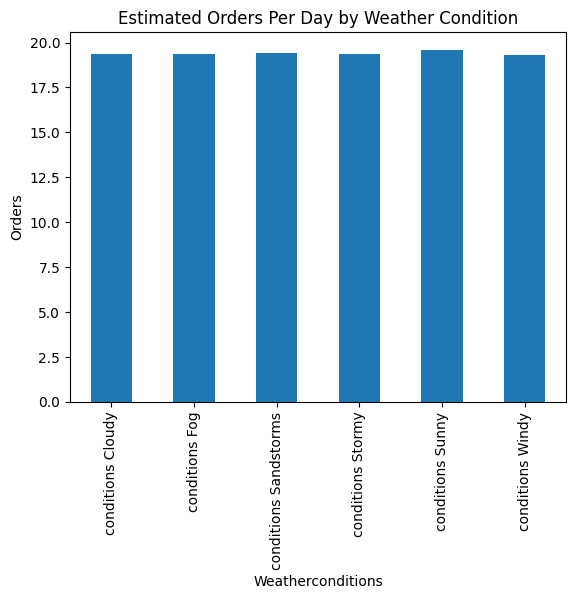

In [ ]:
# 8. Insights and Visualization
import matplotlib.pyplot as plt

df.groupby('Weatherconditions')['Estimated_Orders_Per_Day'].mean().plot(kind='bar')
plt.title('Estimated Orders Per Day by Weather Condition')
plt.ylabel('Orders')
plt.show()


# 9. Conclusion

The project successfully applied the CRISP-DM methodology to develop a data-driven solution.
The results provide actionable insights that help delivery drivers estimate daily workload based on environmental and traffic conditions.